In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns if needed
pd.set_option('display.max_columns', None)

In [2]:
orders = pd.read_csv('orders.csv')
order_products = pd.read_csv('order_products__prior.csv')
products = pd.read_csv('products.csv')
aisles = pd.read_csv('aisles.csv')
departments = pd.read_csv('departments.csv')

In [3]:
print("Orders:", orders.shape)
print("Order Products:", order_products.shape)
print("Products:", products.shape)
print("Aisles:", aisles.shape)
print("Departments:", departments.shape)

Orders: (1041248, 7)
Order Products: (1652760, 4)
Products: (49688, 4)
Aisles: (134, 2)
Departments: (21, 2)


In [4]:
# Display first 5 rows of each dataset

print("Orders Dataset")
display(orders.head())

print("\nOrder Products Dataset")
display(order_products.head())

print("\nProducts Dataset")
display(products.head())

print("\nAisles Dataset")
display(aisles.head())

print("\nDepartments Dataset")
display(departments.head())

Orders Dataset


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1.0,2.0,8.0,NaN
1,2398795,1,prior,2.0,3.0,7.0,15.0
2,473747,1,prior,3.0,3.0,12.0,21.0
3,2254736,1,prior,4.0,4.0,7.0,29.0
4,431534,1,prior,5.0,4.0,15.0,28.0



Order Products Dataset


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1.0
1,2,28985,2,1.0
2,2,9327,3,0.0
3,2,45918,4,1.0
4,2,30035,5,0.0



Products Dataset


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13



Aisles Dataset


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation



Departments Dataset


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [5]:
print("Orders Info")
orders.info()

print("\nOrder Products Info")
order_products.info()

print("\nProducts Info")
products.info()

Orders Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1041248 entries, 0 to 1041247
Data columns (total 7 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                1041248 non-null  int64  
 1   user_id                 1041248 non-null  int64  
 2   eval_set                1041248 non-null  object 
 3   order_number            1041247 non-null  float64
 4   order_dow               1041247 non-null  float64
 5   order_hour_of_day       1041247 non-null  float64
 6   days_since_prior_order  978567 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 55.6+ MB

Order Products Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1652760 entries, 0 to 1652759
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           1652760 non-null  int64  
 1   product_id         1652760 non

In [6]:
print("Missing Values in Orders")
print(orders.isnull().sum())

print("\nMissing Values in Order Products")
print(order_products.isnull().sum())

print("\nMissing Values in Products")
print(products.isnull().sum())

Missing Values in Orders
order_id                      0
user_id                       0
eval_set                      0
order_number                  1
order_dow                     1
order_hour_of_day             1
days_since_prior_order    62681
dtype: int64

Missing Values in Order Products
order_id             0
product_id           0
add_to_cart_order    0
reordered            1
dtype: int64

Missing Values in Products
product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64


In [7]:
print("Duplicate Orders:", orders.duplicated().sum())
print("Duplicate Order Products:", order_products.duplicated().sum())
print("Duplicate Products:", products.duplicated().sum())

Duplicate Orders: 0
Duplicate Order Products: 0
Duplicate Products: 0


In [8]:
# Merge order-product details with order information
df = order_products.merge(
    orders,
    on='order_id',
    how='left'
)

print(df.shape)
df.head()

(1652760, 10)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2,28985,2,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2,9327,3,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2,45918,4,1.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2,30035,5,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Add product details
df = df.merge(
    products,
    on='product_id',
    how='left'
)

print(df.shape)
df.head()

(1652760, 13)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id
0,2,33120,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,Organic Egg Whites,86,16
1,2,28985,2,1.0,NaN,NaN,NaN,NaN,NaN,NaN,Michigan Organic Kale,83,4
2,2,9327,3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Garlic Powder,104,13
3,2,45918,4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,Coconut Butter,19,13
4,2,30035,5,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Natural Sweetener,17,13


In [10]:
# Add aisle names
df = df.merge(
    aisles,
    on='aisle_id',
    how='left'
)

print(df.shape)
df.head()

(1652760, 14)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle
0,2,33120,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,Organic Egg Whites,86,16,eggs
1,2,28985,2,1.0,NaN,NaN,NaN,NaN,NaN,NaN,Michigan Organic Kale,83,4,fresh vegetables
2,2,9327,3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Garlic Powder,104,13,spices seasonings
3,2,45918,4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,Coconut Butter,19,13,oils vinegars
4,2,30035,5,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Natural Sweetener,17,13,baking ingredients


In [11]:
# Add department names
df = df.merge(
    departments,
    on='department_id',
    how='left'
)

print(df.shape)
df.head()

(1652760, 15)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1.0,NaN,NaN,NaN,NaN,NaN,NaN,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Natural Sweetener,17,13,baking ingredients,pantry


In [12]:
print(df.shape)
df.info()

(1652760, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1652760 entries, 0 to 1652759
Data columns (total 15 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                1652760 non-null  int64  
 1   product_id              1652760 non-null  int64  
 2   add_to_cart_order       1652760 non-null  int64  
 3   reordered               1652759 non-null  float64
 4   user_id                 500527 non-null   float64
 5   eval_set                500527 non-null   object 
 6   order_number            500527 non-null   float64
 7   order_dow               500527 non-null   float64
 8   order_hour_of_day       500527 non-null   float64
 9   days_since_prior_order  468354 non-null   float64
 10  product_name            1652760 non-null  object 
 11  aisle_id                1652760 non-null  int64  
 12  department_id           1652760 non-null  int64  
 13  aisle                   1652760 non-null  o

In [13]:
# Save the merged analytical dataset
df.to_csv("instacart_analytics_dataset.csv", index=False)

print("Merged dataset exported successfully!")

Merged dataset exported successfully!


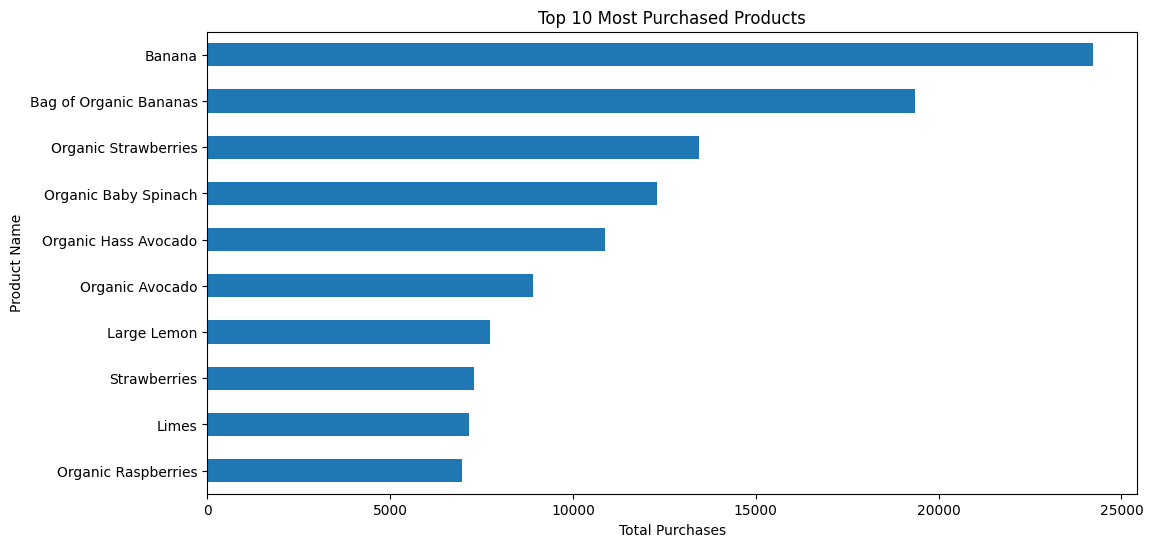

In [14]:
# Top 10 most purchased products
top_products = (
    df.groupby('product_name')['order_id']
      .count()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_products.sort_values().plot(kind='barh')
plt.title('Top 10 Most Purchased Products')
plt.xlabel('Total Purchases')
plt.ylabel('Product Name')
plt.show()

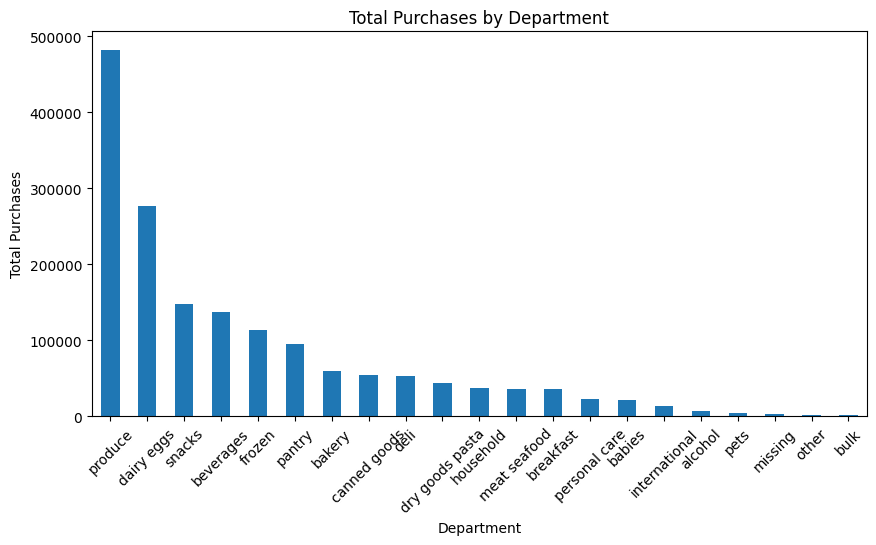

In [15]:
# Top 10 departments
top_departments = (
    df.groupby('department')['order_id']
      .count()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
top_departments.plot(kind='bar')
plt.title('Total Purchases by Department')
plt.xlabel('Department')
plt.ylabel('Total Purchases')
plt.xticks(rotation=45)
plt.show()

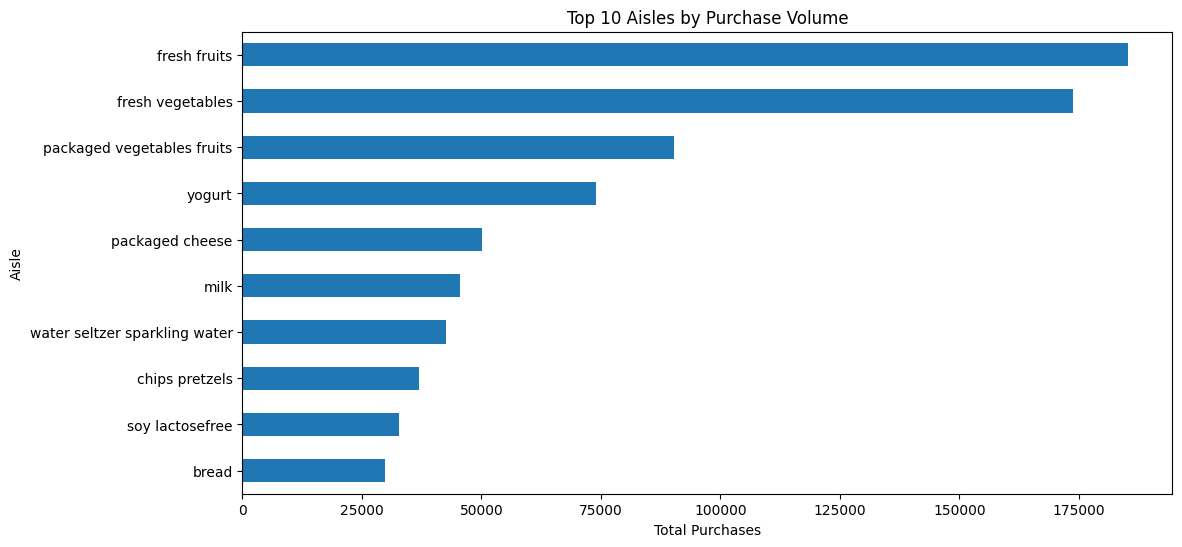

In [16]:
# Top 10 aisles
top_aisles = (
    df.groupby('aisle')['order_id']
      .count()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_aisles.sort_values().plot(kind='barh')
plt.title('Top 10 Aisles by Purchase Volume')
plt.xlabel('Total Purchases')
plt.ylabel('Aisle')
plt.show()

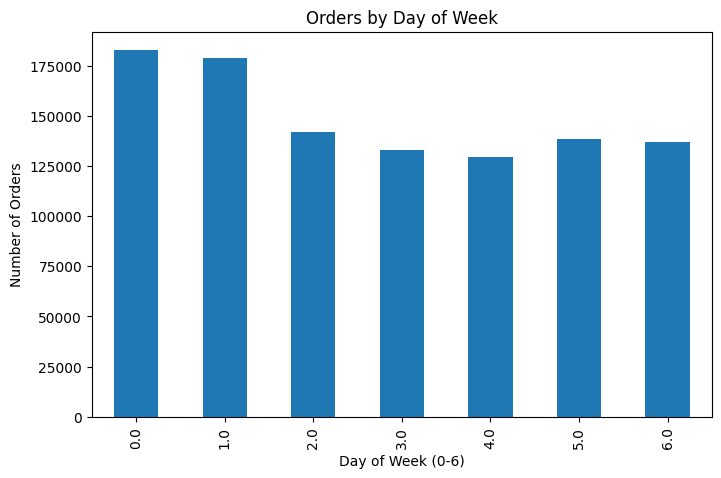

In [17]:
orders_by_day = (
    orders['order_dow']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))
orders_by_day.plot(kind='bar')
plt.title('Orders by Day of Week')
plt.xlabel('Day of Week (0-6)')
plt.ylabel('Number of Orders')
plt.show()

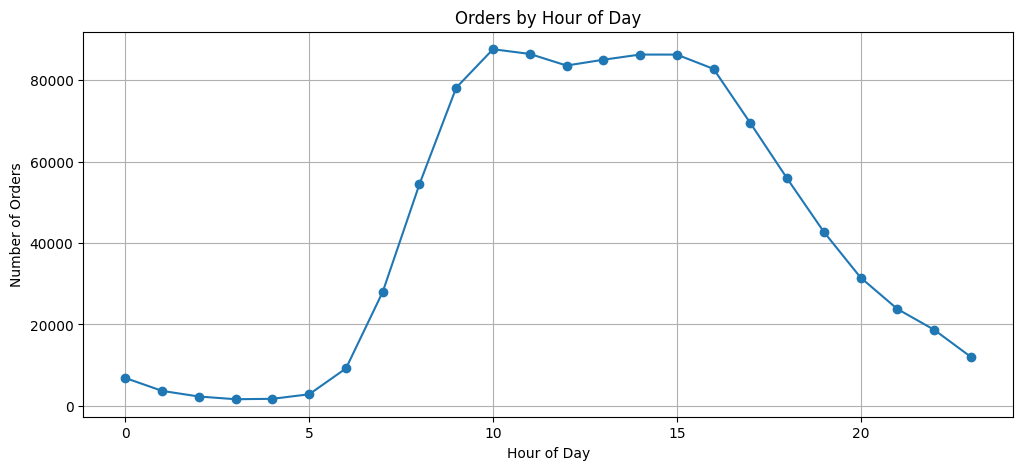

In [18]:
orders_by_hour = (
    orders['order_hour_of_day']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))
orders_by_hour.plot(kind='line', marker='o')
plt.title('Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.grid(True)
plt.show()

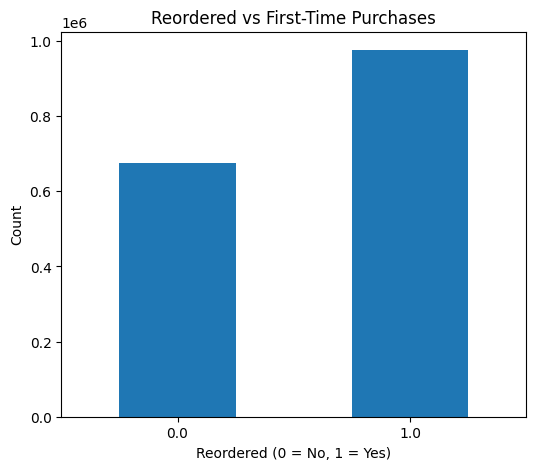

In [19]:
reorder_counts = (
    df['reordered']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6,5))
reorder_counts.plot(kind='bar')
plt.title('Reordered vs First-Time Purchases')
plt.xlabel('Reordered (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

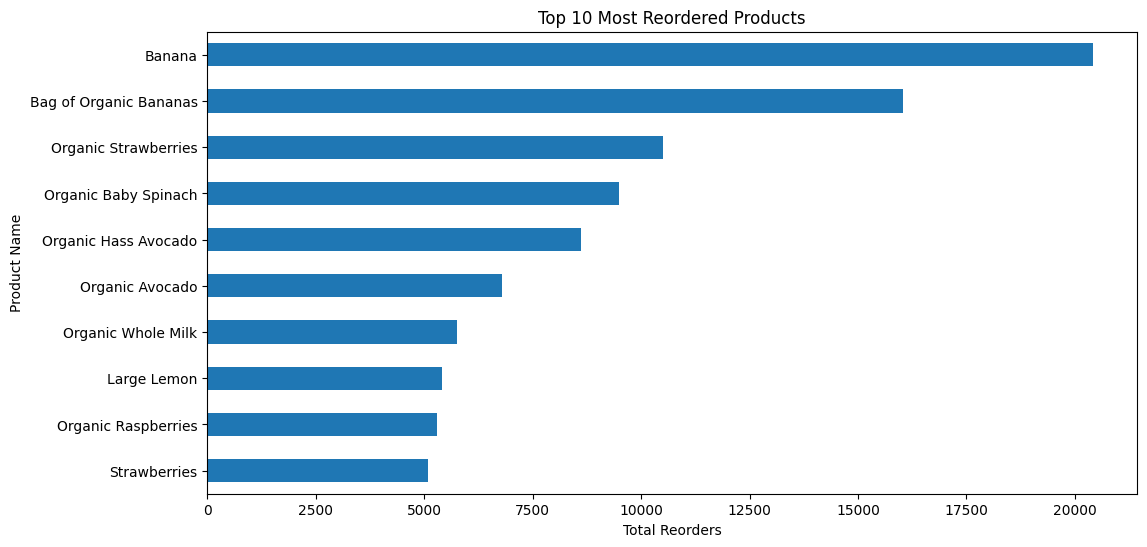

In [20]:
# Top 10 most reordered products
top_reordered = (
    df[df['reordered'] == 1]
    .groupby('product_name')['reordered']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_reordered.sort_values().plot(kind='barh')
plt.title('Top 10 Most Reordered Products')
plt.xlabel('Total Reorders')
plt.ylabel('Product Name')
plt.show()

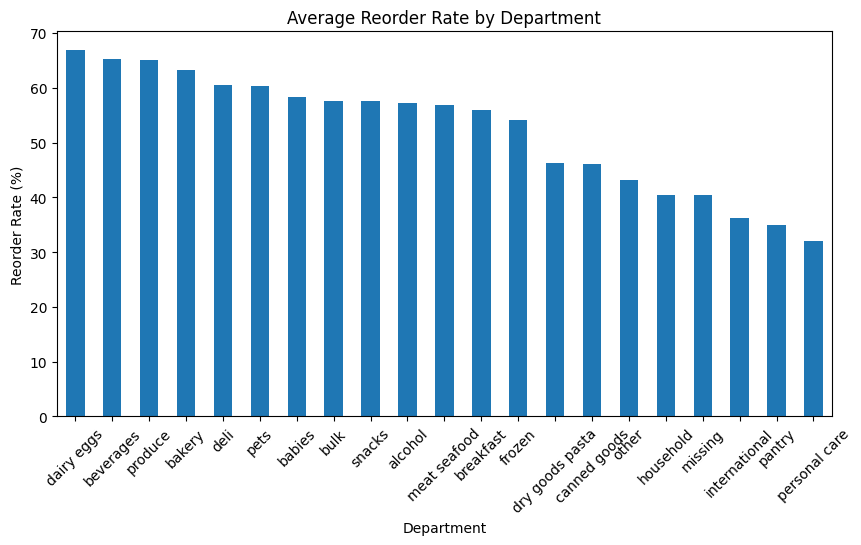

In [21]:
# Average reorder rate by department
dept_reorder = (
    df.groupby('department')['reordered']
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(10,5))
dept_reorder.plot(kind='bar')
plt.title('Average Reorder Rate by Department')
plt.xlabel('Department')
plt.ylabel('Reorder Rate (%)')
plt.xticks(rotation=45)
plt.show()

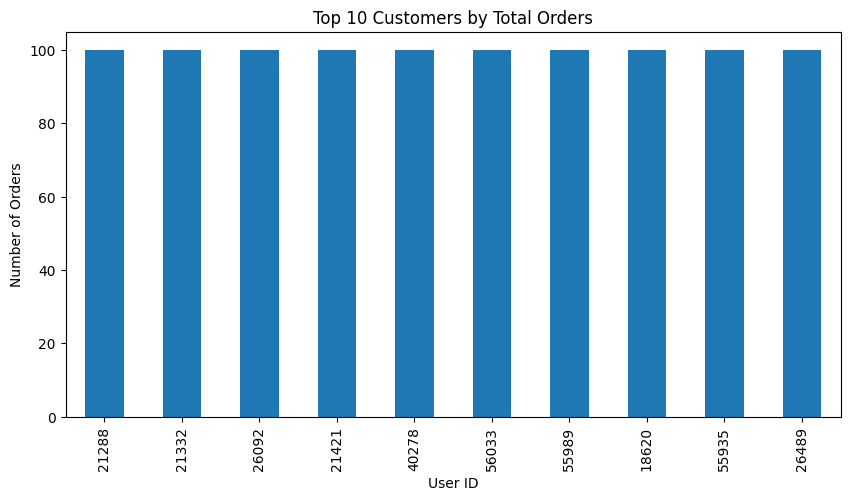

In [22]:
# Top customers
top_customers = (
    orders.groupby('user_id')['order_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')
plt.title('Top 10 Customers by Total Orders')
plt.xlabel('User ID')
plt.ylabel('Number of Orders')
plt.show()

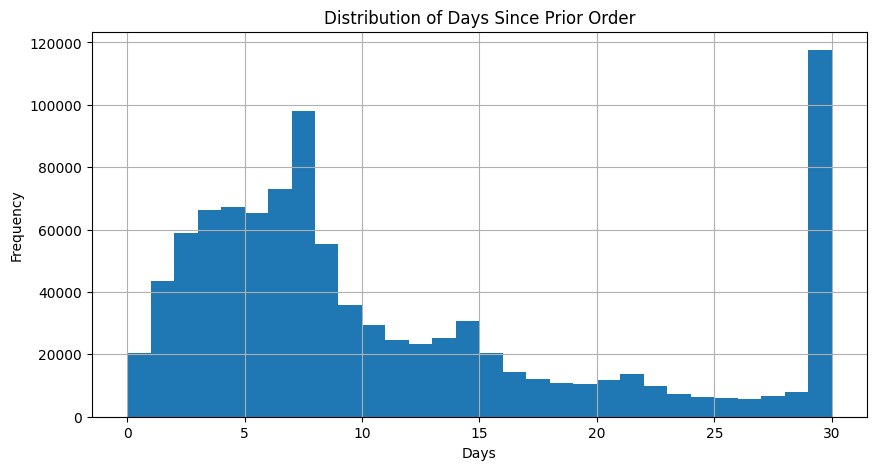

In [23]:
plt.figure(figsize=(10,5))
orders['days_since_prior_order'].dropna().hist(bins=30)
plt.title('Distribution of Days Since Prior Order')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.show()

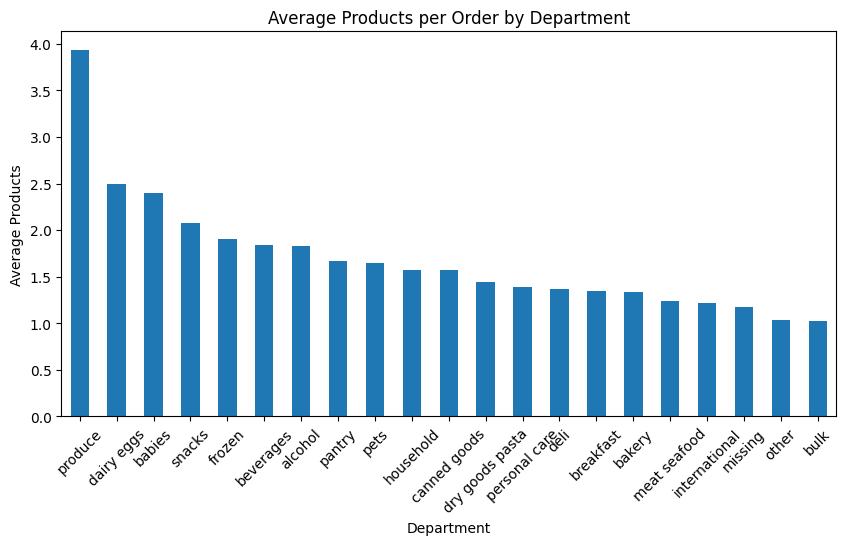

In [24]:
basket_size = (
    df.groupby('department')['order_id']
    .count()
    /
    df.groupby('department')['order_id']
    .nunique()
).sort_values(ascending=False)

plt.figure(figsize=(10,5))
basket_size.plot(kind='bar')
plt.title('Average Products per Order by Department')
plt.xlabel('Department')
plt.ylabel('Average Products')
plt.xticks(rotation=45)
plt.show()

In [25]:
heatmap_data = (
    orders.pivot_table(
        index='order_dow',
        columns='order_hour_of_day',
        values='order_id',
        aggfunc='count',
        fill_value=0
    )
)

heatmap_data.head()

order_hour_of_day,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0
order_dow,,,,,,,,,,,,,,,,,,,,,,,,
0.0,1189,714,437,311,229,371,973,3668,8524,12338,14861,15342,15835,16407,16675,16415,15068,11972,9087,6908,5543,4376,3427,2095
1.0,1089,547,346,240,266,473,1655,5028,10398,15702,16761,15728,14537,14520,14157,14051,13598,11170,8902,6734,4839,3630,2688,1685
2.0,925,467,262,215,235,423,1440,4007,7487,10975,11882,11588,10836,11241,11385,11603,11402,9723,8031,6121,4516,3303,2474,1603
3.0,903,437,284,190,238,391,1342,3779,7014,9888,10958,10720,10154,10433,10536,10966,10619,9315,7614,5740,4124,3130,2525,1509
4.0,797,436,286,200,243,370,1362,3845,6689,9491,10621,10371,9809,9995,10217,10279,10384,8835,7297,5846,4365,3292,2647,1698


## Key Business Insights

1. Bananas and Organic Bananas are the most purchased and most reordered products.
2. The Produce and Dairy Eggs departments contribute the highest purchase volumes.
3. Fresh Fruits and Fresh Vegetables are the busiest aisles.
4. Peak order activity occurs around 10 AM to 3 PM.
5. Customer reorder behavior suggests a stable demand pattern for essential grocery items.
6. These insights can help optimize inventory replenishment and reduce stock-out risks.


